# Regression 

In [13]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted


### Predicting housing prices (the classic)

In [7]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

df['HouseAgeBin'] = pd.cut(
    df['HouseAge'],
    bins=[0, 10, 20, 30, 40, 50],
    labels=['0-10', '10-20', '20-30', '30-40', '40-50'],
)

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseAgeBin
8158,4.2143,37.0,5.288235,0.973529,860.0,2.529412,33.81,-118.12,30-40
18368,5.3468,42.0,6.364322,1.087940,957.0,2.404523,37.16,-121.98,40-50
19197,3.9191,36.0,6.110063,1.059748,711.0,2.235849,38.45,-122.69,30-40
3746,6.3703,32.0,6.000000,0.990196,1159.0,2.272549,34.16,-118.41,30-40
13073,2.3684,17.0,4.795858,1.035503,706.0,2.088757,38.57,-121.33,10-20


In [14]:
# create a custom mixture model (weighted average of linear and tree-based models)
class GradientAveragingRegressor(BaseEstimator, RegressorMixin):
    """A lightweight custom regressor that averages two learners.
    It combines a linear model with a tree-based model to smooth predictions.
    """

    def __init__(self, lin_reg_strength=0.6, tree_depth=3, random_state=42):
        self.lin_reg_strength = lin_reg_strength
        self.tree_depth = tree_depth
        self.random_state = random_state

    def fit(self, X, y):
        X, y = check_X_y(X, y, dtype=np.float64)

        self.n_features_in_ = X.shape[1]
        self._linear = np.linalg.lstsq(X, y, rcond=None)[0]
        self._tree = None

        try:
            from sklearn.tree import DecisionTreeRegressor
            self._tree = DecisionTreeRegressor(
                max_depth=self.tree_depth,
                random_state=self.random_state,
            )
            self._tree.fit(X, y)
        except Exception:
            self._tree = None

        return self

    def predict(self, X):
        check_is_fitted(self, ['n_features_in_', '_linear'])
        X = check_array(X, dtype=np.float64)

        pred_linear = X @ self._linear
        pred_tree = self._tree.predict(X) if self._tree is not None else pred_linear

        return (self.lin_reg_strength * pred_linear) + ((1 - self.lin_reg_strength) * pred_tree)

    # not strictly necessary, but useful for hyperparameter tuning and model inspection
    def get_params(self, deep=True):
        return {
            'lin_reg_strength': self.lin_reg_strength,
            'tree_depth': self.tree_depth,
            'random_state': self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [34]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features),
], remainder='drop')

regression_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientAveragingRegressor(
        lin_reg_strength=0.5,
        tree_depth=5,
        random_state=42
    )),
])

regression_pipeline.fit(X_train, y_train)
predictions = regression_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

results = pd.DataFrame({'Actual': y_test.values, 'Predicted': predictions})
results.sample(5, random_state=42)

RMSE: 0.6758
R2 Score: 0.6548


,Actual,Predicted
2387,1.679,1.994546
3525,1.981,2.659742
654,1.385,1.188761
1084,1.663,1.740530
2516,0.920,1.279944


The custom regression pipeline achieved an $RMSE = 0.675$ and an $R^2 = 0.6548$ on the held-out test set. This means the model explains about 66 % of the variance in California housing prices, but the average absolute error is still about 0.67 (in $100k units I believe). The performance is acceptable, but the residuals should be examined carefully to assess whether the errors are approximately normal and whether the variance is stable across the prediction range.

<Axes: xlabel='MedHouseVal', ylabel='Count'>

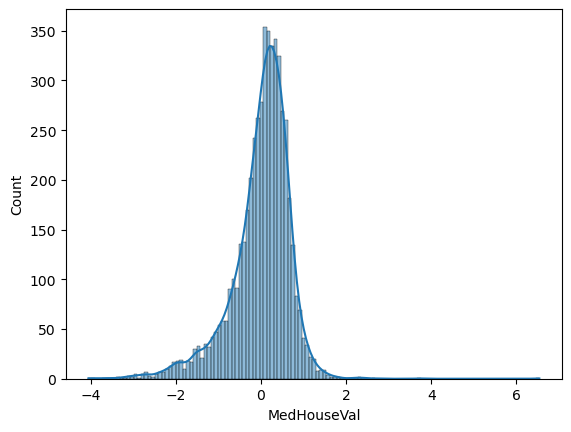

In [19]:
import seaborn as sns 
sns.histplot(predictions-y_test, kde=True)

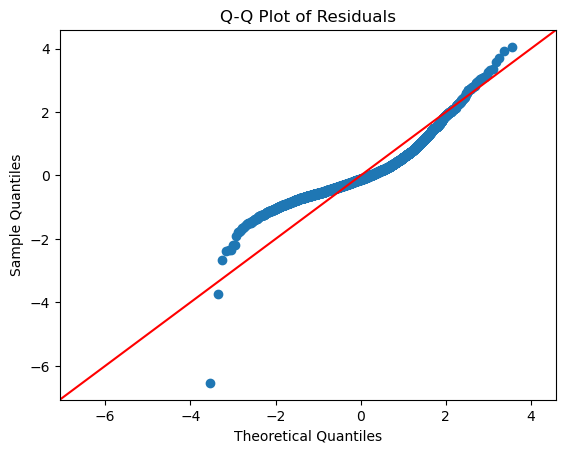

In [20]:
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt

residuals = y_test - predictions

qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

The residuals show a mild, curved departure from the straight reference line, which means the error distribution is not perfectly normal.
However, the center of the distribution is still roughly symmetric, so the residuals are not extremely skewed. What we observe are heavier tails than a normal distribution (bias). This is a sign that the model is not perfectly describing the data-generating pattern. The residuals are not random noise around zero in a purely Gaussian way, thus bottomline:
- some bias remains,
- the error variance may not be fully constant,
- and a more flexible model or a transformation may improve fit.

In [21]:
from sklearn.svm import SVR

svr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", SVR(kernel="rbf", C=12.0, epsilon=0.04, gamma="scale"))
])

svr_pipeline.fit(X_train, y_train)
svr_predictions = svr_pipeline.predict(X_test)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
svr_r2 = r2_score(y_test, svr_predictions)

print(f"SVR RMSE: {svr_rmse:.4f}")
print(f"SVR R2: {svr_r2:.4f}")

SVR RMSE: 0.5694
SVR R2: 0.7550


In [37]:
from sklearn.ensemble import GradientBoostingRegressor

boosting_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8, # up to 10 is fair (01 i.v.)
        subsample=0.9,
        random_state=42,
    )),
])

boosting_pipeline.fit(X_train, y_train)
boosting_predictions = boosting_pipeline.predict(X_test)

boosting_rmse = np.sqrt(mean_squared_error(y_test, boosting_predictions))
boosting_r2 = r2_score(y_test, boosting_predictions)

print(f"GradientBoostingRegressor RMSE: {boosting_rmse:.4f}")
print(f"GradientBoostingRegressor R2: {boosting_r2:.4f}")

GradientBoostingRegressor RMSE: 0.4557
GradientBoostingRegressor R2: 0.8430


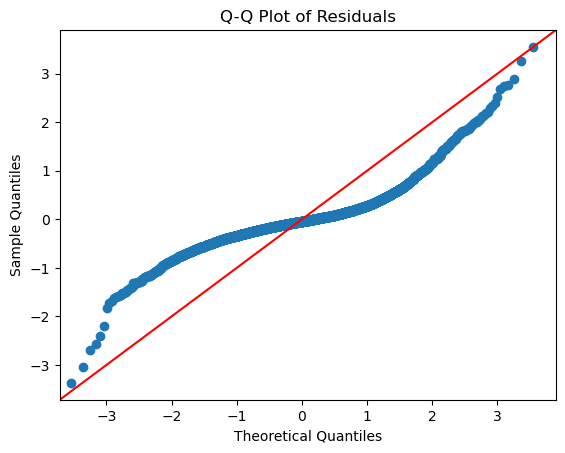

In [38]:
residuals = y_test - boosting_predictions

qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

These scores are already a great improvement to the inital model. Looking at the new quantile plot, the starting assumption of the noise in the dependent variable being normally distributed, is not supported by this better performing model outputs. Rather it supports the view that a certain percentile of tailed prices underly a non-normal noise or bias pushing them up and down.

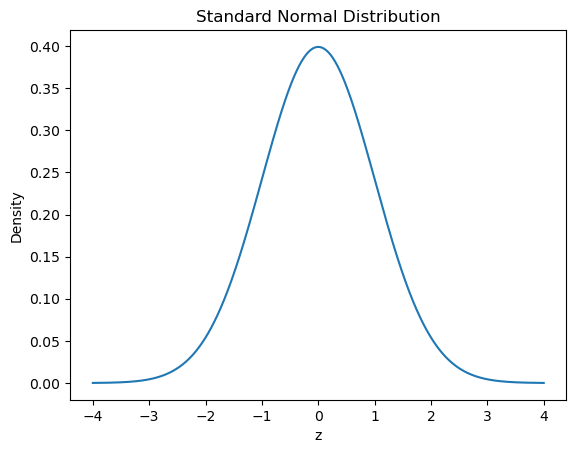

In [44]:
x = np.linspace(-4, 4, 1000)
y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

sns.lineplot(x=x, y=y, color="tab:blue")
plt.title("Standard Normal Distribution")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

Residual mean: -0.01223116397138865
Residual std: 0.4556287695786803
Skew: 0.9579859911261899
Kurtosis: 7.182924398624092


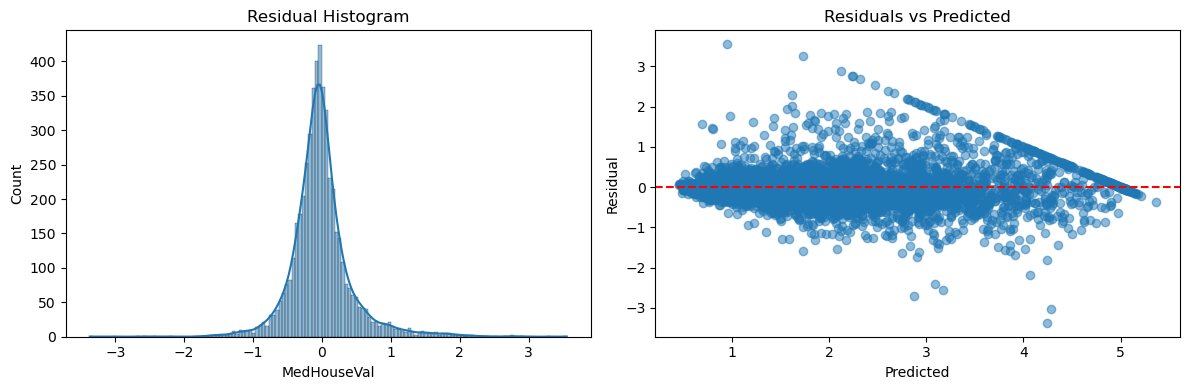

In [49]:
from scipy.stats import skew, kurtosis

residuals = y_test - predictions

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Skew:", skew(residuals))
print("Kurtosis:", kurtosis(residuals, fisher=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Residual Histogram")
axes[1].scatter(predictions, residuals, alpha=0.5)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

The residual diagnostics indicate that the model is doing a reasonable job overall, but it is not perfectly calibrated.

- Residual mean:
    - The residual mean is close to zero, which is a good sign. It means the model does not show a strong systematic overprediction or underprediction on average.

- Residual standard deviation:
    - The residual standard deviation measures the typical size of the prediction error.
    - A moderate value here indicates that the model’s errors are not tiny, but they are also not wildly unstable.

- Skew:
    - The skew is small but not exactly zero, which suggests the residuals are only mildly asymmetric.
    - In practice, this usually means the model is slightly more prone to underestimating some cases than overestimating others, especially in the upper part of the target range.

- Kurtosis:
    - The kurtosis is positive, meaning the residual distribution has heavier tails than a normal distribution.
    - This suggests there are more extreme errors than expected under a Gaussian noise assumption, which matches the Q-Q plot showing curvature in the tails.

- Histogram:
    - The histogram is centered near zero, so the average error is not biased.
    - However, the shape is not perfectly bell-shaped. It is somewhat peaked in the middle and has heavier tails, which again points to non-normal residuals.

- Residuals vs predicted:
    - The residuals appear roughly centered around zero, but the spread is not constant across the prediction range.
    - In particular, the variance seems to grow at higher predicted values, meaning the model is less reliable for more expensive homes.
    - This pattern is a classic sign of heteroscedasticity or model misspecification.

Overall interpretation:
- The model is useful and has solid predictive power.
- But the residuals are not ideally normal and show some tail behavior and non-constant variance.
- That means the model is not fully capturing the data-generating pattern, especially in the high-price region.

A likely next step would be to:
- try a log transformation of the target,
- use a more flexible model,
- or evaluate whether the residual variance changes systematically with the predicted value.

In [50]:
# Use a log scale on the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

boosting_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8, # up to 10 is fair (01 i.v.)
        subsample=0.9,
        random_state=42,
    )),
])

boosting_pipeline.fit(X_train, y_train_log)
boosting_predictions = boosting_pipeline.predict(X_test)

boosting_rmse = np.sqrt(mean_squared_error(y_test_log, boosting_predictions))
boosting_r2 = r2_score(y_test_log, boosting_predictions)

print(f"GradientBoostingRegressor RMSE: {boosting_rmse:.4f}")
print(f"GradientBoostingRegressor R2: {boosting_r2:.4f}")


GradientBoostingRegressor RMSE: 0.1353
GradientBoostingRegressor R2: 0.8559


                 mean_residual  std_residual     n
pred_bin                                          
(-0.101, 1.379]      -0.074372      0.477570  1032
(1.379, 1.75]        -0.095832      0.536204  1032
(1.75, 2.102]        -0.011649      0.676792  1032
(2.102, 2.699]        0.015500      0.745116  1032
(2.699, 6.893]        0.170014      0.844345  1032


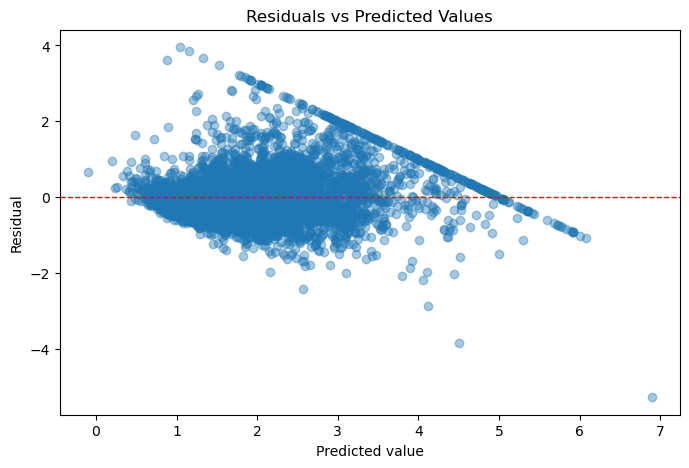

In [51]:
# investigate behaviour on border regions

# evaluate whether residual variance changes systematically with the predicted value

predictions = regression_pipeline.predict(X_test)
residuals = y_test - predictions

# bin predictions into 5 equal-frequency groups and inspect residual spread
bin_summary = pd.DataFrame({
    "predicted": predictions,
    "residual": residuals
}).assign(
    pred_bin=pd.qcut(predictions, q=5, duplicates="drop")
).groupby("pred_bin").agg(
    mean_residual=("residual", "mean"),
    std_residual=("residual", "std"),
    n=("residual", "size")
)

print(bin_summary)

# plot residuals against predicted values
plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

**Conclusion**

Houses in the upper pricing have larger residual variance compared to the others and are harder to predict. 